In [ ]:
import pandas as _hex_pandas
import datetime as _hex_datetime
import json as _hex_json

In [ ]:
hex_scheduled = _hex_json.loads("false")

In [ ]:
hex_user_email = _hex_json.loads("\"example-user@example.com\"")

In [ ]:
hex_user_attributes = _hex_json.loads("{}")

In [ ]:
hex_run_context = _hex_json.loads("\"logic\"")

In [ ]:
hex_timezone = _hex_json.loads("\"UTC\"")

In [ ]:
hex_project_id = _hex_json.loads("\"019c0cdb-0056-7339-be4c-77a0105467b7\"")

In [ ]:
hex_project_name = _hex_json.loads("\"Supervised and Unsupervised Learning\"")

In [ ]:
hex_status = _hex_json.loads("\"\"")

In [ ]:
hex_categories = _hex_json.loads("[]")

In [ ]:
hex_color_palette = _hex_json.loads("[\"#4C78A8\",\"#F58518\",\"#E45756\",\"#72B7B2\",\"#54A24B\",\"#EECA3B\",\"#B279A2\",\"#FF9DA6\",\"#9D755D\",\"#BAB0AC\"]")

In [ ]:
import pandas as pd

df = pd.read_csv('wikipedia.csv')
df

,page_id,title,url,content_length,num_links,num_sections,num_references,all_categories,meta_categories,science_categories,num_categories,summary_length,avg_sentence_length,last_revision_date,num_languages,languages,rating
0,47262,2 Pallas,https://en.wikipedia.org/wiki/2_Pallas,49731,184,16,138,"['1802 in science', 'Articles containing Ancie...",['Articles containing Ancient Greek (to 1453)-...,"['1802 in science', 'Astronomical objects disc...",20,2198,24.40,2025-11-25T20:44:17Z,92,"['af', 'gsw', 'an', 'anp', 'ar', 'arz', 'ast',...",GA
1,71318,100-year flood,https://en.wikipedia.org/wiki/100-year_flood,24708,265,10,43,"['Actuarial science', 'Articles with short des...","['Articles with short description', 'CS1 maint...","['Actuarial science', 'Extreme value data', 'F...",9,698,25.20,2025-12-01T13:21:16Z,9,"['ar', 'de', 'es', 'fa', 'fr', 'ms', 'nb', 'sv...",C
2,175149,'Pataphysics,https://en.wikipedia.org/wiki/%27Pataphysics,49610,51,24,65,"[""'Pataphysics"", 'Alfred Jarry', 'All articles...",['All articles containing potentially dated st...,"[""'Pataphysics"", 'Alfred Jarry', 'Fictional ph...",19,273,20.50,2026-01-04T15:47:15Z,24,"['ast', 'bg', 'ca', 'cs', 'de', 'el', 'es', 'e...",C
3,786020,"1,4-Butanediol","https://en.wikipedia.org/wiki/1,4-Butanediol",19934,0,12,32,"['1,4-Butanediyl compounds', 'Alcohol solvents...","['All articles needing additional references',...","['1,4-Butanediyl compounds', 'Alcohol solvents...",25,369,25.00,2026-01-08T01:18:38Z,26,"['ar', 'az', 'azb', 'ca', 'de', 'eo', 'es', 'e...",B
4,1110853,*Dyēus,https://en.wikipedia.org/wiki/*Dy%C4%93us,62518,0,18,60,"['Articles containing Albanian-language text',...","['Articles containing Albanian-language text',...","['Etymologies', 'Proto-Indo-European gods', 'R...",28,841,20.67,2025-12-27T19:49:48Z,18,"['ar', 'ca', 'cs', 'es', 'ext', 'fa', 'fi', 'f...",B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16467,5065997,Zirconium(IV) silicate,https://en.wikipedia.org/wiki/Zirconium(IV)_si...,6474,102,5,9,['Articles containing unverified chemical info...,['Articles containing unverified chemical info...,"['High-κ dielectrics', 'Refractory materials',...",16,391,8.57,2025-09-24T00:32:38Z,14,"['ar', 'azb', 'cs', 'de', 'es', 'fa', 'fr', 'i...",START
16468,24215517,Zirconium(IV) sulfate,https://en.wikipedia.org/wiki/Zirconium(IV)_su...,4083,346,3,4,['Articles containing unverified chemical info...,['Articles containing unverified chemical info...,"['Sulfates', 'Zirconium(IV) compounds']",14,354,15.00,2025-06-24T01:25:10Z,14,"['ar', 'azb', 'bn', 'de', 'fa', 'fi', 'fr', 'i...",STUB
16469,34411,Zodiac,https://en.wikipedia.org/wiki/Zodiac,67343,500,18,99,['All Wikipedia articles written in American E...,['All Wikipedia articles written in American E...,"['Ancient astronomy', 'Astrological signs', 'A...",32,1703,24.91,2025-12-17T05:15:17Z,107,"['af', 'ar', 'arz', 'ast', 'az', 'ba', 'bcl', ...",C
16470,34527,Zodiacal light,https://en.wikipedia.org/wiki/Zodiacal_light,22395,360,10,35,"['All Wikipedia articles in need of updating',...","['All Wikipedia articles in need of updating',...","['Light sources', 'Observational astronomy', '...",11,1697,24.82,2026-01-23T05:19:23Z,55,"['af', 'ar', 'ary', 'az', 'bg', 'ca', 'ckb', '...",C


In [ ]:
df['num_languages'] = df['num_languages'] + 1
leaky_quality_cols = ['meta_All stub articles', 'meta_Good articles', 'meta_Featured articles']
df.drop(columns=leaky_quality_cols, inplace=True, axis=1, errors='ignore')
df.to_csv('wikipedia.csv', index=False)

print(f"Updated num_languages (+1 to all articles) and dropped redundant categories")
print(f"Sample language counts: {df['num_languages'].head(10).tolist()}")
print(f"Min languages: {df['num_languages'].min()}, Max languages: {df['num_languages'].max()}")


Updated num_languages (+1 to all articles) and dropped redundant categories
Sample language counts: [93, 10, 25, 27, 19, 4, 4, 15, 16, 20]
Min languages: 1, Max languages: 329


In [ ]:
import ast
from collections import Counter

# Parse all lists to count unique values
all_langs = []
all_cats = []

for idx, row in df.iterrows():
    langs = ast.literal_eval(row['languages'])
    all_langs.extend(langs)
    
    cats = ast.literal_eval(row['all_categories'])
    all_cats.extend(cats)

# Count uniques
unique_langs = set(all_langs)
unique_cats = set(all_cats)
lang_freq = Counter(all_langs)
cat_freq = Counter(all_cats)

print(f"DATASET OVERVIEW")
print(f"=" * 80)
print(f"Total articles: {len(df):,}")
print(f"Unique languages: {len(unique_langs):,}")
print(f"Unique categories: {len(unique_cats):,}")
print(f"\nPotential one-hot encoded features:")
print(f"  Languages: {len(unique_langs):,} binary columns")
print(f"  Categories: {len(unique_cats):,} binary columns")
print(f"  TOTAL: {len(unique_langs) + len(unique_cats):,} new features")

print(f"\n" + "=" * 80)
print(f"LANGUAGE DISTRIBUTION")
print(f"=" * 80)
print(f"Top 20 most common languages:")
for lang, count in lang_freq.most_common(20):
    pct = count / len(df) * 100
    print(f"  {lang:5} → {count:3} articles ({pct:5.1f}%)")

print(f"\n" + "=" * 80)
print(f"CATEGORY DISTRIBUTION")
print(f"=" * 80)
print(f"Top 30 most common categories:")
for cat, count in cat_freq.most_common(30):
    pct = count / len(df) * 100
    print(f"  {cat[:60]:60} → {count:3} articles ({pct:5.1f}%)")

DATASET OVERVIEW
Total articles: 16,472
Unique languages: 342
Unique categories: 22,878

Potential one-hot encoded features:
  Languages: 342 binary columns
  Categories: 22,878 binary columns
  TOTAL: 23,220 new features

LANGUAGE DISTRIBUTION
Top 20 most common languages:
  es    → 4852 articles ( 29.5%)
  ar    → 4830 articles ( 29.3%)
  fr    → 4828 articles ( 29.3%)
  de    → 4778 articles ( 29.0%)
  fa    → 4761 articles ( 28.9%)
  zh    → 4571 articles ( 27.8%)
  ru    → 4473 articles ( 27.2%)
  ja    → 4464 articles ( 27.1%)
  ca    → 4378 articles ( 26.6%)
  pt    → 4353 articles ( 26.4%)
  ko    → 4349 articles ( 26.4%)
  it    → 4322 articles ( 26.2%)
  uk    → 4210 articles ( 25.6%)
  pl    → 4063 articles ( 24.7%)
  nl    → 4049 articles ( 24.6%)
  cs    → 3935 articles ( 23.9%)
  id    → 3845 articles ( 23.3%)
  fi    → 3752 articles ( 22.8%)
  sv    → 3619 articles ( 22.0%)
  tr    → 3554 articles ( 21.6%)

CATEGORY DISTRIBUTION
Top 30 most common categories:
  Articles 

In [ ]:
# Parse the three category types
all_cats = []
meta_cats = []
science_cats = []

for idx, row in df.iterrows():
    all_c = ast.literal_eval(row['all_categories'])
    all_cats.extend(all_c)
    
    meta_c = ast.literal_eval(row['meta_categories'])
    meta_cats.extend(meta_c)
    
    science_c = ast.literal_eval(row['science_categories'])
    science_cats.extend(science_c)

# Count frequencies
all_freq = Counter(all_cats)
meta_freq = Counter(meta_cats)
science_freq = Counter(science_cats)

# Get unique counts
unique_all = set(all_cats)
unique_meta = set(meta_cats)
unique_science = set(science_cats)

print(f"CATEGORY TYPE COMPARISON")
print(f"=" * 80)
print(f"Total articles: {len(df):,}\n")

print(f"{'Category Type':<20} {'Unique':<10} {'Total Occurrences':<20} {'Avg per Article':<15}")
print(f"{'-'*20} {'-'*10} {'-'*20} {'-'*15}")
print(f"{'All Categories':<20} {len(unique_all):<10,} {len(all_cats):<20,} {len(all_cats)/len(df):<15.2f}")
print(f"{'Meta Categories':<20} {len(unique_meta):<10,} {len(meta_cats):<20,} {len(meta_cats)/len(df):<15.2f}")
print(f"{'Science Categories':<20} {len(unique_science):<10,} {len(science_cats):<20,} {len(science_cats)/len(df):<15.2f}")

print(f"\n{'Meta % of All:':<20} {len(unique_meta)/len(unique_all)*100:.1f}% unique, {len(meta_cats)/len(all_cats)*100:.1f}% of occurrences")
print(f"{'Science % of All:':<20} {len(unique_science)/len(unique_all)*100:.1f}% unique, {len(science_cats)/len(all_cats)*100:.1f}% of occurrences")

print(f"\n" + "=" * 80)
print(f"TOP 15 CATEGORIES BY TYPE")
print(f"=" * 80)

print(f"\nALL CATEGORIES:")
for cat, count in all_freq.most_common(15):
    pct = count / len(df) * 100
    print(f"  {cat[:60]:60} → {count:5,} ({pct:5.1f}%)")

print(f"\nMETA CATEGORIES:")
for cat, count in meta_freq.most_common(15):
    pct = count / len(df) * 100
    print(f"  {cat[:60]:60} → {count:5,} ({pct:5.1f}%)")

print(f"\nSCIENCE CATEGORIES:")
for cat, count in science_freq.most_common(15):
    pct = count / len(df) * 100
    print(f"  {cat[:60]:60} → {count:5,} ({pct:5.1f}%)")

CATEGORY TYPE COMPARISON
Total articles: 16,472

Category Type        Unique     Total Occurrences    Avg per Article
-------------------- ---------- -------------------- ---------------
All Categories       22,878     195,299              11.86          
Meta Categories      6,052      135,319              8.22           
Science Categories   16,826     59,980               3.64           

Meta % of All:       26.5% unique, 69.3% of occurrences
Science % of All:    73.5% unique, 30.7% of occurrences

TOP 15 CATEGORIES BY TYPE

ALL CATEGORIES:
  Articles with short description                              → 15,912 ( 96.6%)
  Short description is different from Wikidata                 → 10,260 ( 62.3%)
  Short description matches Wikidata                           → 5,948 ( 36.1%)
  All articles with unsourced statements                       → 5,751 ( 34.9%)
  Webarchive template wayback links                            → 4,990 ( 30.3%)
  All articles needing additional references   

In [ ]:
import ast
from collections import Counter

# Calculate coverage for top-N items
def calculate_coverage(df, column_name, freq_counter, top_n_list):
    """Calculate % of articles covered by top-N items"""
    results = []
    
    for n in top_n_list:
        top_n_items = set([item for item, count in freq_counter.most_common(n)])
        
        articles_covered = 0
        articles_with_zero_top_n = 0
        
        for idx, row in df.iterrows():
            items = ast.literal_eval(row[column_name])
            
            if any(item in top_n_items for item in items):
                articles_covered += 1
            elif len(items) > 0:
                articles_with_zero_top_n += 1
        
        coverage_pct = articles_covered / len(df) * 100
        results.append((n, articles_covered, coverage_pct, articles_with_zero_top_n))
    
    return results

# Calculate frequencies for meta and science categories
meta_cats = []
science_cats = []

for idx, row in df.iterrows():
    meta_c = ast.literal_eval(row['meta_categories'])
    meta_cats.extend(meta_c)
    
    science_c = ast.literal_eval(row['science_categories'])
    science_cats.extend(science_c)

meta_freq = Counter(meta_cats)
science_freq = Counter(science_cats)

# Check for articles with 0 languages
articles_with_zero_langs = 0
for idx, row in df.iterrows():
    langs = ast.literal_eval(row['languages'])
    if len(langs) == 0:
        articles_with_zero_langs += 1

print(f"DATA QUALITY CHECK")
print(f"=" * 80)
print(f"Total articles: {len(df):,}")
print(f"English-only articles: {articles_with_zero_langs:,} ({articles_with_zero_langs/len(df)*100:.1f}%)")

# Calculate coverage for languages
print(f"\n" + "=" * 80)
print(f"LANGUAGE COVERAGE")
print(f"=" * 80)
lang_coverage = calculate_coverage(df, 'languages', lang_freq, [20, 30, 50, 100])
for n, count, pct, zero_top_n in lang_coverage:
    print(f"Top {n:3} languages  → {count:5,} articles covered ({pct:5.1f}%) | {zero_top_n:,} with 0 top-{n} languages")

# Calculate coverage for meta categories
print(f"\n" + "=" * 80)
print(f"META CATEGORY COVERAGE")
print(f"=" * 80)
meta_coverage = calculate_coverage(df, 'meta_categories', meta_freq, [20, 30, 50, 100])
for n, count, pct, zero_top_n in meta_coverage:
    print(f"Top {n:3} meta cats   → {count:5,} articles covered ({pct:5.1f}%) | {zero_top_n:,} with 0 top-{n} meta cats")

# Calculate coverage for science categories
print(f"\n" + "=" * 80)
print(f"SCIENCE CATEGORY COVERAGE")
print(f"=" * 80)
science_coverage = calculate_coverage(df, 'science_categories', science_freq, [20, 30, 50, 100])
for n, count, pct, zero_top_n in science_coverage:
    print(f"Top {n:3} science cats → {count:5,} articles covered ({pct:5.1f}%) | {zero_top_n:,} with 0 top-{n} science cats")

DATA QUALITY CHECK
Total articles: 16,472
English-only articles: 10,735 (65.2%)

LANGUAGE COVERAGE
Top  20 languages  → 5,693 articles covered ( 34.6%) | 44 with 0 top-20 languages
Top  30 languages  → 5,705 articles covered ( 34.6%) | 32 with 0 top-30 languages
Top  50 languages  → 5,720 articles covered ( 34.7%) | 17 with 0 top-50 languages
Top 100 languages  → 5,727 articles covered ( 34.8%) | 10 with 0 top-100 languages

META CATEGORY COVERAGE
Top  20 meta cats   → 16,260 articles covered ( 98.7%) | 78 with 0 top-20 meta cats
Top  30 meta cats   → 16,265 articles covered ( 98.7%) | 73 with 0 top-30 meta cats
Top  50 meta cats   → 16,291 articles covered ( 98.9%) | 47 with 0 top-50 meta cats
Top 100 meta cats   → 16,310 articles covered ( 99.0%) | 28 with 0 top-100 meta cats

SCIENCE CATEGORY COVERAGE
Top  20 science cats → 1,709 articles covered ( 10.4%) | 14,711 with 0 top-20 science cats
Top  30 science cats → 2,105 articles covered ( 12.8%) | 14,315 with 0 top-30 science cats
To

In [ ]:
# Find articles with 0 top-20 categories
top_20_cats = set([cat for cat, count in cat_freq.most_common(20)])

articles_without_top20 = []
for idx, row in df.iterrows():
    cats = ast.literal_eval(row['all_categories'])
    if not any(cat in top_20_cats for cat in cats):
        articles_without_top20.append((idx, cats))

print(f"Articles without any top-20 categories: {len(articles_without_top20)}")

# Find all categories in these articles (excluding top 20)
remaining_cats_counter = Counter()
for idx, cats in articles_without_top20:
    for cat in cats:
        if cat not in top_20_cats:
            remaining_cats_counter[cat] += 1

# Greedy algorithm: find minimum set to cover all articles
uncovered_articles = set(range(len(articles_without_top20)))
selected_categories = []

while uncovered_articles:
    # Find category that covers the most uncovered articles
    best_cat = None
    best_coverage = 0
    
    for cat, _ in remaining_cats_counter.items():
        if cat in [c for c, _ in selected_categories]:
            continue
        
        # Count how many uncovered articles this category would cover
        coverage = 0
        for i in uncovered_articles:
            idx, cats = articles_without_top20[i]
            if cat in cats:
                coverage += 1
        
        if coverage > best_coverage:
            best_coverage = coverage
            best_cat = cat
    
    if best_cat is None:
        break
    
    # Add this category and mark articles as covered
    selected_categories.append((best_cat, best_coverage))
    newly_covered = set()
    for i in uncovered_articles:
        idx, cats = articles_without_top20[i]
        if best_cat in cats:
            newly_covered.add(i)
    
    uncovered_articles -= newly_covered

print(f"\n" + "=" * 80)
print(f"MINIMUM CATEGORY SET (beyond top 20)")
print(f"=" * 80)
print(f"Categories needed: {len(selected_categories)}")
print(f"Articles covered: {len(articles_without_top20) - len(uncovered_articles)} / {len(articles_without_top20)}")
print(f"\nCategories (in order of coverage):")
for i, (cat, coverage) in enumerate(selected_categories[:15], 1):
    print(f"{i:2}. {cat[:70]:70} → covers {coverage:3} articles")

Articles without any top-20 categories: 212

MINIMUM CATEGORY SET (beyond top 20)
Categories needed: 131
Articles covered: 212 / 212

Categories (in order of coverage):
 1. All articles lacking in-text citations                                 → covers  15 articles
 2. Economics models                                                       → covers   7 articles
 3. Wikipedia articles incorporating text from the Congressional Research  → covers   6 articles
 4. Electronic design                                                      → covers   5 articles
 5. Economics theorems                                                     → covers   5 articles
 6. Electric transformers                                                  → covers   5 articles
 7. Paradoxes in economics                                                 → covers   4 articles
 8. K-theory                                                               → covers   4 articles
 9. Wikipedia articles incorporating a citation from th

In [ ]:
# Drop unnecessary columns
wiki_clean = df.drop(columns=['page_id', 'title', 'url', 'all_categories', 'science_categories']).copy()

print(f"Original columns: {df.shape[1]}")
print(f"After dropping: {wiki_clean.shape[1]}")
print(f"\nRemaining columns:")
print(list(wiki_clean.columns))

Original columns: 17
After dropping: 12

Remaining columns:
['content_length', 'num_links', 'num_sections', 'num_references', 'meta_categories', 'num_categories', 'summary_length', 'avg_sentence_length', 'last_revision_date', 'num_languages', 'languages', 'rating']


In [ ]:
# Get top 100 meta categories
meta_cats_all = []
for idx, row in wiki_clean.iterrows():
    meta_c = ast.literal_eval(row['meta_categories'])
    meta_cats_all.extend(meta_c)

meta_freq = Counter(meta_cats_all)
top_100_meta = set([cat for cat, count in meta_freq.most_common(100)])

# Filter to articles with at least one top-100 meta category
def has_top_meta(row):
    meta_c = ast.literal_eval(row['meta_categories'])
    return any(cat in top_100_meta for cat in meta_c)

wiki_filtered = wiki_clean[wiki_clean.apply(has_top_meta, axis=1)].copy().reset_index(drop=True)

print(f"Before filtering: {len(wiki_clean):,} articles")
print(f"After filtering:  {len(wiki_filtered):,} articles")
print(f"Removed:          {len(wiki_clean) - len(wiki_filtered):,} articles ({(len(wiki_clean) - len(wiki_filtered))/len(wiki_clean)*100:.1f}%)")

Before filtering: 16,472 articles
After filtering:  16,310 articles
Removed:          162 articles (1.0%)


In [ ]:
import ast
import pandas as pd

# Explore rating distribution across meta categories
rating_category_data = []

for idx, row in wiki_filtered.iterrows():
    rating = row['rating']
    meta_c = ast.literal_eval(row['meta_categories'])
    
    for cat in meta_c:
        if cat in top_100_meta:
            rating_category_data.append({'category': cat, 'rating': rating})

rating_cat_df = pd.DataFrame(rating_category_data)

# Overall rating distribution
print(f"OVERALL RATING DISTRIBUTION")
print(f"=" * 80)
rating_counts = wiki_filtered['rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    pct = count / len(wiki_filtered) * 100
    print(f"{rating:5} → {count:6,} articles ({pct:5.1f}%)")

# Rating distribution by category (top 20 categories)
print(f"\n" + "=" * 80)
print(f"RATING DISTRIBUTION BY TOP 20 META CATEGORIES")
print(f"=" * 80)

top_20_cats = [cat for cat, count in meta_freq.most_common(20) if cat in top_100_meta]

for cat in top_20_cats[:10]:  # Show first 10 for readability
    cat_ratings = rating_cat_df[rating_cat_df['category'] == cat]['rating'].value_counts()
    total = cat_ratings.sum()
    
    print(f"\n{cat[:70]}")
    print(f"  Total occurrences: {total:,}")
    
    rating_dist = []
    for rating in ['GA', 'B', 'C', 'START', 'STUB']:
        if rating in cat_ratings.index:
            count = cat_ratings[rating]
            pct = count / total * 100
            rating_dist.append(f"{rating}:{pct:.0f}%")
    
    print(f"  Distribution: {', '.join(rating_dist)}")

OVERALL RATING DISTRIBUTION
B     →  2,593 articles ( 15.9%)
C     →  5,834 articles ( 35.8%)
FA    →    136 articles (  0.8%)
GA    →    402 articles (  2.5%)
START →  5,829 articles ( 35.7%)
STUB  →  1,516 articles (  9.3%)

RATING DISTRIBUTION BY TOP 20 META CATEGORIES

Articles with short description
  Total occurrences: 15,912
  Distribution: GA:3%, B:16%, C:36%, START:36%, STUB:8%

Short description is different from Wikidata
  Total occurrences: 10,260
  Distribution: GA:3%, B:18%, C:38%, START:34%, STUB:5%

Short description matches Wikidata
  Total occurrences: 5,948
  Distribution: GA:2%, B:14%, C:32%, START:39%, STUB:12%

All articles with unsourced statements
  Total occurrences: 5,751
  Distribution: GA:1%, B:23%, C:47%, START:27%, STUB:2%

Webarchive template wayback links
  Total occurrences: 4,990
  Distribution: GA:4%, B:27%, C:45%, START:21%, STUB:2%

All articles needing additional references
  Total occurrences: 3,180
  Distribution: GA:0%, B:13%, C:40%, START:38%, 

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# Get top 20 languages
all_langs = []
for idx, row in wiki_filtered.iterrows():
    langs = ast.literal_eval(row['languages'])
    all_langs.extend(langs)

lang_freq = Counter(all_langs)
top_20_langs = [lang for lang, count in lang_freq.most_common(20)]

print(f"Top 20 languages: {len(top_20_langs)}")
print(f"Top 100 meta categories: {len(top_100_meta)}")
print(f"\nTop 20 languages:")
for i, lang in enumerate(top_20_langs, 1):
    count = lang_freq[lang]
    pct = count / len(wiki_filtered) * 100
    print(f"  {i:2}. {lang:5} → {count:5,} ({pct:5.1f}%)")

Top 20 languages: 20
Top 100 meta categories: 100

Top 20 languages:
   1. es    → 4,849 ( 29.7%)
   2. ar    → 4,825 ( 29.6%)
   3. fr    → 4,819 ( 29.5%)
   4. de    → 4,769 ( 29.2%)
   5. fa    → 4,758 ( 29.2%)
   6. zh    → 4,567 ( 28.0%)
   7. ru    → 4,472 ( 27.4%)
   8. ja    → 4,460 ( 27.3%)
   9. ca    → 4,376 ( 26.8%)
  10. pt    → 4,349 ( 26.7%)
  11. ko    → 4,347 ( 26.7%)
  12. it    → 4,319 ( 26.5%)
  13. uk    → 4,204 ( 25.8%)
  14. pl    → 4,059 ( 24.9%)
  15. nl    → 4,046 ( 24.8%)
  16. cs    → 3,935 ( 24.1%)
  17. id    → 3,843 ( 23.6%)
  18. fi    → 3,752 ( 23.0%)
  19. sv    → 3,619 ( 22.2%)
  20. tr    → 3,554 ( 21.8%)


In [ ]:
def filter_and_encode(df, column_name, top_items, prefix):
    """
    Filter items to top-N list and one-hot encode them.
    
    Parameters:
    - df: DataFrame with the column to encode
    - column_name: Name of column containing list-like strings
    - top_items: Set or list of items to keep
    - prefix: Prefix for encoded column names
    
    Returns:
    - DataFrame with binary encoded columns
    """
    # Parse and filter to top items only
    filtered_lists = []
    for idx, row in df.iterrows():
        items = ast.literal_eval(row[column_name])
        filtered = [item for item in items if item in top_items]
        filtered_lists.append(filtered)
    
    # One-hot encode
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(filtered_lists)
    
    # Create DataFrame with proper column names
    encoded_df = pd.DataFrame(
        encoded,
        columns=[f'{prefix}_{item}' for item in mlb.classes_],
        index=df.index
    )
    
    return encoded_df

print("Function defined: filter_and_encode()")
print("  - Filters items to top-N list")
print("  - One-hot encodes filtered items")
print("  - Returns DataFrame with binary columns")

Function defined: filter_and_encode()
  - Filters items to top-N list
  - One-hot encodes filtered items
  - Returns DataFrame with binary columns


In [ ]:
# Encode meta categories (top 100)
meta_encoded = filter_and_encode(wiki_filtered, 'meta_categories', top_100_meta, 'meta')

# Encode languages (top 20)
lang_encoded = filter_and_encode(wiki_filtered, 'languages', top_20_langs, 'lang')

print(f"Encoding complete:")
print(f"  Meta categories: {meta_encoded.shape[1]} binary features")
print(f"  Languages:       {lang_encoded.shape[1]} binary features")
print(f"  Total new features: {meta_encoded.shape[1] + lang_encoded.shape[1]}")

Encoding complete:
  Meta categories: 100 binary features
  Languages:       20 binary features
  Total new features: 120


In [ ]:
# Combine all features into final preprocessed dataset
wiki_preprocessed = pd.concat([
    wiki_filtered.drop(['meta_categories', 'languages'], axis=1),
    meta_encoded,
    lang_encoded
], axis=1)

# Reorder: all columns except rating, then rating at end
cols = [col for col in wiki_preprocessed.columns if col != 'rating'] + ['rating']
wiki_preprocessed = wiki_preprocessed[cols]

wiki_preprocessed.to_csv("wiki_preprocessed_non_standardized.csv", index=False)

print(f"FINAL PREPROCESSED DATASET")
print(f"=" * 80)
print(f"Shape: {wiki_preprocessed.shape}")
print(f"  Articles: {wiki_preprocessed.shape[0]:,}")
print(f"  Features: {wiki_preprocessed.shape[1]:,}")
print(f"\nFeature breakdown:")
print(f"  Original features: {len(wiki_filtered.drop(['meta_categories', 'languages'], axis=1).columns)}")
print(f"  Meta category features: {meta_encoded.shape[1]}")
print(f"  Language features: {lang_encoded.shape[1]}")
print(f"\nColumn types:")
print(f"  rating (target)")
print(f"  content_length, num_links, num_images, num_refs, num_sections (numerical)")
print(f"  meta_* (100 binary category features)")
print(f"  lang_* (20 binary language features)")

wiki_preprocessed.head()

FINAL PREPROCESSED DATASET
Shape: (16310, 130)
  Articles: 16,310
  Features: 130

Feature breakdown:
  Original features: 10
  Meta category features: 100
  Language features: 20

Column types:
  rating (target)
  content_length, num_links, num_images, num_refs, num_sections (numerical)
  meta_* (100 binary category features)
  lang_* (20 binary language features)


,content_length,num_links,num_sections,num_references,num_categories,summary_length,avg_sentence_length,last_revision_date,num_languages,meta_All Wikipedia articles in need of updating,...,lang_ko,lang_nl,lang_pl,lang_pt,lang_ru,lang_sv,lang_tr,lang_uk,lang_zh,rating
0,49731,184,16,138,20,2198,24.40,2025-11-25T20:44:17Z,93,0,...,1,1,1,1,1,1,1,1,1,GA
1,24708,265,10,43,9,698,25.20,2025-12-01T13:21:16Z,10,0,...,0,0,0,0,0,1,0,0,1,C
2,49610,51,24,65,19,273,20.50,2026-01-04T15:47:15Z,25,0,...,1,1,1,1,1,1,1,1,0,C
3,19934,0,12,32,25,369,25.00,2026-01-08T01:18:38Z,27,0,...,1,1,1,1,1,1,0,0,1,B
4,62518,0,18,60,28,841,20.67,2025-12-27T19:49:48Z,19,0,...,1,1,1,0,1,0,0,1,1,B


In [ ]:
from sklearn.preprocessing import StandardScaler

wiki_preprocessed_non_standardized = pd.read_csv('wiki_preprocessed_non_standardized.csv')

# Convert last_revision_date to UNIX timestamp
wiki_preprocessed_non_standardized['last_revision_date'] = pd.to_datetime(wiki_preprocessed['last_revision_date']).astype(int) / 10**9

# Move rating to the end
rating_col = wiki_preprocessed_non_standardized.pop('rating')

# Standardize all features
scaler = StandardScaler()
wiki_preprocessed_scaled = pd.DataFrame(
    scaler.fit_transform(wiki_preprocessed_non_standardized),
    columns=wiki_preprocessed_non_standardized.columns,
    index=wiki_preprocessed_non_standardized.index
)

# Add rating back at the end
wiki_preprocessed = wiki_preprocessed_scaled
wiki_preprocessed['rating'] = rating_col

wiki_preprocessed.to_csv("wiki_preprocessed.csv", index=False)

print(f"Preprocessed and standardized dataset shape: {wiki_preprocessed.shape}")
print(f"\nFirst few rows:")
wiki_preprocessed.head()

Preprocessed and standardized dataset shape: (16310, 130)

First few rows:


,content_length,num_links,num_sections,num_references,num_categories,summary_length,avg_sentence_length,last_revision_date,num_languages,meta_All Wikipedia articles in need of updating,...,lang_ko,lang_nl,lang_pl,lang_pt,lang_ru,lang_sv,lang_tr,lang_uk,lang_zh,rating
0,0.463824,1.050210,0.097002,1.348153,1.051630,1.507736,1.062436,0.276048,2.040743,-0.147003,...,1.658919,1.741017,1.737306,1.658399,1.627003,1.872637,1.894517,1.696950,1.603519,GA
1,-0.190402,1.689322,-0.392964,-0.023409,-0.385801,-0.071611,1.132955,0.306641,-0.239986,-0.147003,...,-0.602802,-0.574377,-0.575604,-0.602991,-0.614627,1.872637,-0.527839,-0.589293,1.603519,C
2,0.460661,0.000803,0.750290,0.294216,0.920954,-0.519093,0.718656,0.489911,0.172194,-0.147003,...,1.658919,1.741017,1.737306,1.658399,1.627003,1.872637,1.894517,1.696950,-0.623629,C
3,-0.315219,-0.401601,-0.229642,-0.182221,1.705008,-0.418014,1.115325,0.508166,0.227151,-0.147003,...,1.658919,1.741017,1.737306,1.658399,1.627003,1.872637,-0.527839,-0.589293,1.603519,B
4,0.798141,-0.401601,0.260324,0.222028,2.097034,0.078953,0.733641,0.447822,0.007322,-0.147003,...,1.658919,1.741017,1.737306,-0.602991,1.627003,-0.534006,-0.527839,1.696950,1.603519,B


In [ ]:
from sklearn.model_selection import train_test_split

# Split: 70% train, 15% validation, 15% test
# First split: separate out test set
train_val, test = train_test_split(
    wiki_preprocessed, 
    test_size=0.15, 
    random_state=42,
    stratify=wiki_preprocessed['rating']
)

# Second split: separate train from validation
train, validation = train_test_split(
    train_val, 
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=42,
    stratify=train_val['rating']
)

# Save to CSV files
train.to_csv('train.csv', index=False)
validation.to_csv('validation.csv', index=False)
test.to_csv('test.csv', index=False)

print(f"DATA SPLIT COMPLETE")
print(f"=" * 80)
print(f"Total articles: {len(wiki_preprocessed):,}")
print(f"\nSplit sizes:")
print(f"  Train:      {len(train):6,} ({len(train)/len(wiki_preprocessed)*100:5.1f}%)")
print(f"  Validation: {len(validation):6,} ({len(validation)/len(wiki_preprocessed)*100:5.1f}%)")
print(f"  Test:       {len(test):6,} ({len(test)/len(wiki_preprocessed)*100:5.1f}%)")

print(f"\nRating distribution (train):")
for rating, count in train['rating'].value_counts().sort_index().items():
    pct = count / len(train) * 100
    print(f"  {rating:5} → {count:5,} ({pct:5.1f}%)")

print(f"\nFiles saved:")
print(f"  train.csv")
print(f"  validation.csv")
print(f"  test.csv")

DATA SPLIT COMPLETE
Total articles: 16,310

Split sizes:
  Train:      11,423 ( 70.0%)
  Validation:  2,440 ( 15.0%)
  Test:        2,447 ( 15.0%)

Rating distribution (train):
  B     → 1,816 ( 15.9%)
  C     → 4,086 ( 35.8%)
  FA    →    96 (  0.8%)
  GA    →   282 (  2.5%)
  START → 4,082 ( 35.7%)
  STUB  → 1,061 (  9.3%)

Files saved:
  train.csv
  validation.csv
  test.csv


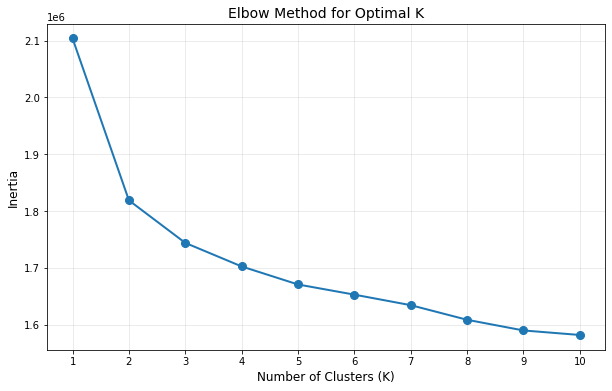

Inertia values:
K=1: 2103990.00
K=2: 1818746.47
K=3: 1743845.66
K=4: 1702350.14
K=5: 1670581.70
K=6: 1652664.58
K=7: 1634117.54
K=8: 1608379.53
K=9: 1589571.62
K=10: 1581619.92


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = wiki_preprocessed.drop(['rating'], axis=1, errors='ignore')

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    print(f"K={k}: {inertia:.2f}")


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

wiki_preprocessed['cluster'] = clusters
clustered_data = wiki_preprocessed

clustered_data.to_csv("clusters.csv", index=False)

print(f"Cluster sizes:")
print(np.bincount(clusters))
print(f"\nInertia: {kmeans.inertia_:.2f}")


Cluster sizes:
[7607 3765  599  150  924 1906  992  367]

Inertia: 1608379.53


In [ ]:
import pandas as pd

# Load non-standardized data for interpretable statistics
clustered_data = pd.read_csv('wiki_preprocessed_non_standardized.csv')
clustered_data['cluster'] = clusters
clustered_data.to_csv('non_standardized_w_clusters.csv', index=False)

# Build consolidated rating distribution table
rating_dist_data = {}
total_articles = len(clustered_data)
for cluster_id in sorted(clustered_data['cluster'].unique()):
    cluster_data = clustered_data[clustered_data['cluster'] == cluster_id]
    rating_counts = cluster_data['rating'].value_counts()
    total = len(cluster_data)
    
    rating_dist_data[f'Cluster {cluster_id}'] = {
        'n_articles': f"{total} ({100*total/total_articles:.1f}%)",
        **{rating: f"{rating_counts.get(rating, 0)} ({100*rating_counts.get(rating, 0)/total:.1f}%)" 
           for rating in ['GA', 'B', 'C', 'START', 'STUB']}
    }

rating_dist_table = pd.DataFrame(rating_dist_data).T
rating_dist_table = rating_dist_table[['n_articles', 'GA', 'B', 'C', 'START', 'STUB']]
rating_dist_table.to_csv('rating_distribution_table.csv', index=True)
rating_dist_table


,n_articles,GA,B,C,START,STUB
Cluster 0,7607 (46.6%),72 (0.9%),624 (8.2%),2628 (34.5%),3848 (50.6%),426 (5.6%)
Cluster 1,3765 (23.1%),95 (2.5%),908 (24.1%),1799 (47.8%),912 (24.2%),38 (1.0%)
Cluster 2,599 (3.7%),105 (17.5%),246 (41.1%),154 (25.7%),12 (2.0%),0 (0.0%)
Cluster 3,150 (0.9%),0 (0.0%),24 (16.0%),68 (45.3%),50 (33.3%),8 (5.3%)
Cluster 4,924 (5.7%),6 (0.6%),93 (10.1%),140 (15.2%),417 (45.1%),267 (28.9%)
Cluster 5,1906 (11.7%),117 (6.1%),609 (32.0%),921 (48.3%),221 (11.6%),7 (0.4%)
Cluster 6,992 (6.1%),2 (0.2%),9 (0.9%),33 (3.3%),221 (22.3%),727 (73.3%)
Cluster 7,367 (2.3%),5 (1.4%),80 (21.8%),91 (24.8%),148 (40.3%),43 (11.7%)


In [ ]:
rating_map = {'GA': 5, 'B': 4, 'C': 3, 'START': 2, 'STUB': 1}
wiki_clustered = pd.read_csv('clusters.csv')
wiki_clustered['rating_numeric'] = wiki_clustered['rating'].map(rating_map)

cluster_avg_rating = wiki_clustered.groupby('cluster')['rating_numeric'].mean().reset_index()
cluster_avg_rating.columns = ['Cluster', 'Avg Rating']

total_articles = len(wiki_clustered)
cluster_sizes = wiki_clustered.groupby('cluster').size()
cluster_avg_rating['% Total'] = cluster_avg_rating['Cluster'].map(
    lambda c: f"{100 * cluster_sizes[c] / total_articles:.1f}%"
)

cluster_avg_rating['Rank'] = cluster_avg_rating['Avg Rating'].rank(ascending=False).astype(int)
cluster_avg_rating = cluster_avg_rating[['Cluster', '% Total', 'Avg Rating', 'Rank']]
cluster_avg_rating = cluster_avg_rating.sort_values('Rank')
cluster_avg_rating

,Cluster,% Total,Avg Rating,Rank
2,2,3.7%,3.858801,1
5,5,11.7%,3.324267,2
1,1,23.1%,3.029318,3
3,3,0.9%,2.720000,4
7,7,2.3%,2.607629,5
0,0,46.6%,2.482495,6
4,4,5.7%,2.083424,7
6,6,6.1%,1.324597,8


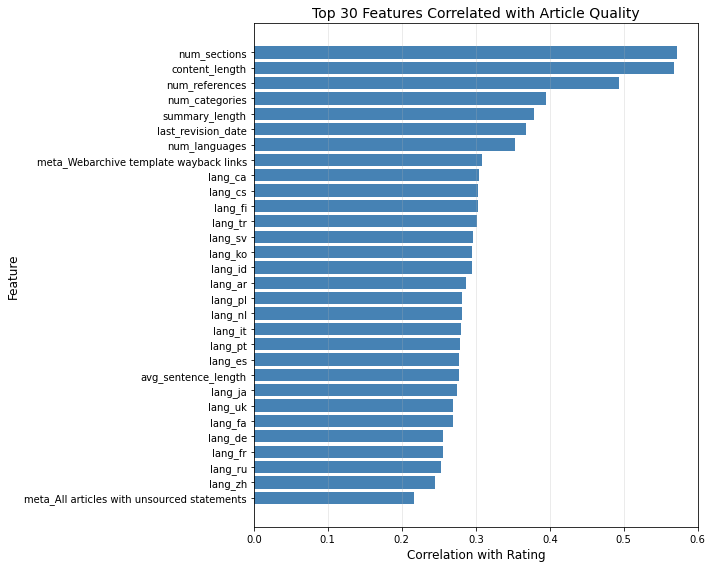


Top 30 features most correlated with rating:

  num_sections                                 : 0.5718
  content_length                               : 0.5681
  num_references                               : 0.4932
  num_categories                               : 0.3943
  summary_length                               : 0.3782
  last_revision_date                           : 0.3680
  num_languages                                : 0.3529
  meta_Webarchive template wayback links       : 0.3089
  lang_ca                                      : 0.3041
  lang_cs                                      : 0.3036
  lang_fi                                      : 0.3029
  lang_tr                                      : 0.3015
  lang_sv                                      : 0.2966
  lang_ko                                      : 0.2949
  lang_id                                      : 0.2948
  lang_ar                                      : 0.2863
  lang_pl                                      : 0.2820
 

In [ ]:
correlations = wiki_clustered[feature_cols].corrwith(wiki_clustered['rating_numeric']).sort_values(ascending=False)

top_30 = correlations.head(30)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_30)), top_30.values, color='steelblue')
plt.yticks(range(len(top_30)), top_30.index)
plt.xlabel('Correlation with Rating', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 30 Features Correlated with Article Quality', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 30 features most correlated with rating:\n")
for feature, corr in top_30.items():
    print(f"  {feature:45s}: {corr:.4f}")

Languages correlate decently with ratings, but they don't mean much on their own. Focusing on maximizing them would violate Goodhart's law. It could be that better rated articles usually have their first version in a foreign language, and English builds on top of it, but it's not clear, and verifying it right now would be intractable. We would have to compare the earliest edit of each article in each language to see.



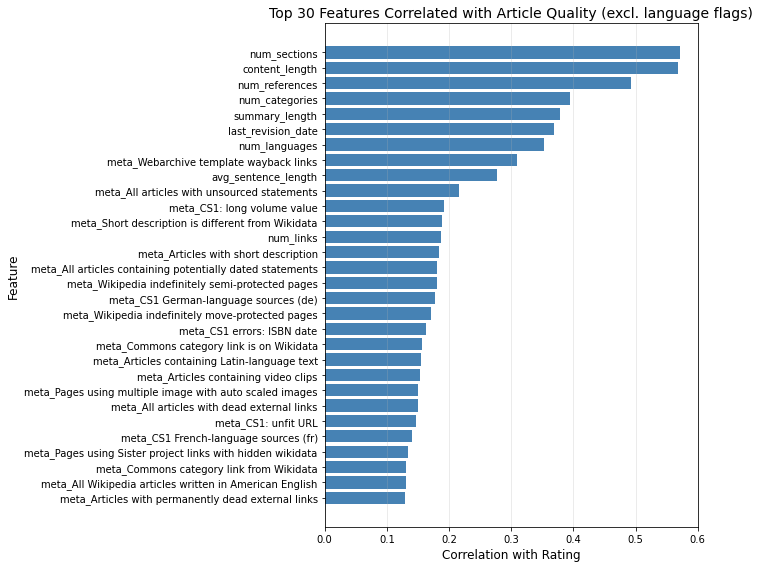


Top 30 features most correlated with rating (excl. language flags):

  num_sections                                 : 0.5718
  content_length                               : 0.5681
  num_references                               : 0.4932
  num_categories                               : 0.3943
  summary_length                               : 0.3782
  last_revision_date                           : 0.3680
  num_languages                                : 0.3529
  meta_Webarchive template wayback links       : 0.3089
  avg_sentence_length                          : 0.2776
  meta_All articles with unsourced statements  : 0.2164
  meta_CS1: long volume value                  : 0.1921
  meta_Short description is different from Wikidata: 0.1887
  num_links                                    : 0.1873
  meta_Articles with short description         : 0.1835
  meta_All articles containing potentially dated statements: 0.1802
  meta_Wikipedia indefinitely semi-protected pages: 0.1799
  meta_CS1 Germ

In [ ]:
feature_cols_no_lang = [col for col in feature_cols if not col.startswith('lang_')]

correlations_no_lang = wiki_clustered[feature_cols_no_lang].corrwith(wiki_clustered['rating_numeric']).sort_values(ascending=False)

top_30_no_lang = correlations_no_lang.head(30)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_30_no_lang)), top_30_no_lang.values, color='steelblue')
plt.yticks(range(len(top_30_no_lang)), top_30_no_lang.index)
plt.xlabel('Correlation with Rating', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 30 Features Correlated with Article Quality (excl. language flags)', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 30 features most correlated with rating (excl. language flags):\n")
for feature, corr in top_30_no_lang.items():
    print(f"  {feature:45s}: {corr:.4f}")

Apparently, sentence length is the least predictive of the numeric features, by an 8% margin.

Now, the category "Webarchive template wayback links" is interesting. Articles under that category have references to Wayback Machine or Archive.is pages i.e. pages that no longer exist. Probably reflective of the Lindy effect. These articles must be older, with their references frequently checked. If they no longer exist, then they point to the Wayback Machine. Could also be a function of the editors looking for earlier sources about the topic, to avoid revisionism.



In [ ]:
wayback_col = 'meta_Webarchive template wayback links'

corr_wayback_age = wiki_clustered[wayback_col].corr(wiki_clustered['last_revision_date'])
print(f"Correlation (wayback links vs last_revision_date): {corr_wayback_age:.4f}")

Correlation (wayback links vs last_revision_date): 0.1986


In [ ]:
from scipy import stats

wayback = wiki_clustered[wayback_col]
rating = wiki_clustered['rating_numeric']
age = pd.to_numeric(wiki_clustered['last_revision_date'], errors='coerce')

# Drop NaNs for clean regression
mask = ~(wayback.isna() | rating.isna() | age.isna())
wayback, rating, age = wayback[mask], rating[mask], age[mask]

# Residuals after removing age effect
wayback_resid = wayback - (stats.linregress(age, wayback).slope * age + stats.linregress(age, wayback).intercept)
rating_resid = rating - (stats.linregress(age, rating).slope * age + stats.linregress(age, rating).intercept)

partial_corr = wayback_resid.corr(rating_resid)
raw_corr = wayback.corr(rating)

print(f"Raw correlation (wayback vs rating):                    {raw_corr:.4f}")
print(f"Partial correlation (wayback vs rating | age):          {partial_corr:.4f}")
print(f"Drop when controlling for age:                          {raw_corr - partial_corr:.4f} ({100*(raw_corr - partial_corr)/raw_corr:.1f}%)")

Raw correlation (wayback vs rating):                    0.3089
Partial correlation (wayback vs rating | age):          0.2591
Drop when controlling for age:                          0.0498 (16.1%)


It seems to me that, controlling for age, wayback links are predictive of quality, indicated by the small drop in correlation, from .31 to .26, when I do the partial correlation.



In [ ]:
# Key features to display
key_features = ['content_length', 'num_links', 'num_sections', 'num_references', 
                'num_categories', 'summary_length', 'num_languages']

# Build consolidated table
cluster_means = {}
for cluster_id in sorted(wiki_clustered['cluster'].unique()):
    cluster_data = wiki_clustered[wiki_clustered['cluster'] == cluster_id]
    cluster_means[f'Cluster {cluster_id}'] = {
        feature: cluster_data[feature].mean() 
        for feature in key_features if feature in cluster_data.columns
    }

# Convert to DataFrame
cluster_summary_table = pd.DataFrame(cluster_means).T

# Add cluster size with percentage
total_articles = len(wiki_clustered)
cluster_summary_table['n_articles'] = [
    f"{len(wiki_clustered[wiki_clustered['cluster'] == i])} ({100*len(wiki_clustered[wiki_clustered['cluster'] == i])/total_articles:.1f}%)"
    for i in sorted(wiki_clustered['cluster'].unique())
]

# Rearrange columns to put n_articles first
cluster_summary_table = cluster_summary_table[['n_articles'] + key_features]

cluster_summary_table


,n_articles,content_length,num_links,num_sections,num_references,num_categories,summary_length,num_languages
Cluster 0,234 (1.4%),52292.256410,19.811966,20.397436,81.568376,15.829060,745.512821,3.910256
Cluster 1,8125 (49.8%),15449.599754,8.461415,9.486277,18.283815,7.953969,390.851323,2.646892
Cluster 2,3396 (20.8%),32165.230860,126.025618,16.534452,39.244111,11.409305,1314.067432,49.381920
Cluster 3,362 (2.2%),16920.314917,69.204420,9.389503,29.140884,18.107735,372.174033,13.629834
Cluster 4,2173 (13.3%),65230.742292,7.583065,26.120571,98.667740,18.572941,1013.107685,2.930971
Cluster 5,241 (1.5%),102737.746888,173.112033,29.842324,169.593361,30.253112,1815.365145,100.481328
Cluster 6,926 (5.7%),9335.977322,37.541037,5.703024,16.012959,13.280778,163.085313,4.717063
Cluster 7,853 (5.2%),109603.643611,247.091442,36.288394,171.400938,25.045721,2058.915592,107.672919


In [ ]:
cluster_summary_table.to_csv('cluster_summary_table.csv', index=True)

In [ ]:
"""
from sklearn.decomposition import PCA

X = wiki_preprocessed.drop(['rating', 'cluster'], axis=1)

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

wiki_preprocessed['PC1'] = principal_components[:, 0]
wiki_preprocessed['PC2'] = principal_components[:, 1]
"""

Explained variance ratio: [0.25171381 0.08253996]
Total variance explained: 0.3343
